# Load data

In [0]:
from sklearn.datasets import fetch_openml
import time

# 1. Carregar dataset Adult Income com retry para lidar com erros temporários
max_retries = 3
for attempt in range(max_retries):
    try:
        adult = fetch_openml(name='adult', version=2, as_frame=True)
        df = adult.frame.copy()
        break
    except Exception as e:
        if attempt < max_retries - 1:
            print(f"Tentativa {attempt + 1} falhou: {e}. Tentando novamente em 2 segundos...")
            time.sleep(2)
        else:
            print(f"Todas as {max_retries} tentativas falharam.")
            raise

# 1. EDA (10%)

a) Identifique a dimensão do dataset: número de linhas e colunas.   
b) Verifique o tipo de variável presente em cada coluna (numérica, categórica, etc.).   
c) Avalie a quantidade de valores em falta (missing values) e proceda ao respetivo tratamento.  
d) Analise o balanceamento das classes na variável alvo.

# 2. Divisão do dataset (5%)

a) Divida os dados em conjuntos de treino, validação e teste, utilizando uma proporção de 60%, 20% e 20%, respetivamente, garantindo a estratificação da variável alvo.

# 3. Identificação e tratamento de variáveis (10%)

a) Identifique quais as variáveis categóricas e quais as numéricas.  
b) Realize uma análise exploratória de dados (EDA) breve, avaliando o tipo e a qualidade da informação disponível.  
c) Trate as variáveis categóricas de forma adequada (por exemplo, one-hot encoding).    
d) Aplique escalonamento às variáveis numéricas.

# 4. Modelação e validação (60%)

a) Utilize os modelos de Regressão Logística e Random Forest para construir um processo de modelação que permita identificar o melhor modelo.  
b) Considere que o objetivo principal é maximizar a identificação correta de rendimentos superiores a 50.000 dólares (i.e., maximizar a sensibilidade/recall da classe positiva).   
c) Utilize técnicas avançadas como Grid Search, Pipelines e Cross-Validation para garantir a robustez e otimização do modelo.

# 5. Justificações e reflexões (15%)

a) Escreva uma breve justificação para cada uma das decisões tomadas durante o processo de pré-processamento e modelação.   
b) Garanta coerência e rigor na metodologia adotada.    
c) Expresse a sua opinião fundamentada sobre a utilização de variáveis sensíveis, tais como género ou raça, na identificação do rendimento, considerando implicações éticas e de justiça.

# 6. Desenvolvimento do Exame


## Data Understanding

In [0]:
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Dimensão do dataset

In [0]:
# a) Identificar a dimensão do dataset: número de linhas e colunas.
df.shape

(48842, 15)

### Tipo de variável presente em cada coluna

In [0]:
# b) tipo de variável presente em cada coluna
df.info() #method

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Dimensões e tipos de dados
print(f"Shape: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes}")
print(f"\nPrimeiras linhas:")
df.head()

Shape: (48842, 15)

Tipos de dados:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object

Primeiras linhas:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Lista de Nomes das Colunas

In [0]:
# Listar nomes das colunas
colunas = df.columns.tolist()
print("Colunas no DataFrame:")
for i, col in enumerate(colunas, 1):
    print(f"{i}. {col}")

Colunas no DataFrame:
1. age
2. workclass
3. fnlwgt
4. education
5. education-num
6. marital-status
7. occupation
8. relationship
9. race
10. sex
11. capital-gain
12. capital-loss
13. hours-per-week
14. native-country
15. class


In [0]:
# 3.a) Identificação de variáveis numéricas e categóricas
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_vars = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Variáveis Numéricas: {num_vars}")
print(f"Variáveis Categóricas: {cat_vars}")

Variáveis Numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Variáveis Categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'class']


### Análise do balanceamento das classes na variável target

In [0]:
# d) balanceamento das classes na variável alvo
print("Distribuição da variável alvo:")
print(df['class'].value_counts(normalize=True) * 100)

Distribuição da variável alvo:
class
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64


## Data Cleaning

### Tratamento de Linhas Duplicadas

In [0]:
duplicates = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicates}")

Número de linhas duplicadas: 52


In [0]:
print(f"Shape antes: {df.shape}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape depois: {df.shape}")

Shape antes: (48842, 15)
Shape depois: (48790, 15)


In [0]:
print(f"Duplicatas restantes: {df.duplicated().sum()}")

Duplicatas restantes: 0


### Tratamento de 'Missing Values'


In [0]:
# c) quantidade de valores em falta (missing values)
missing = df.isnull().sum()
print("Valores em falta por coluna:")
print(missing[missing > 0])

Valores em falta por coluna:
workclass         2795
occupation        2805
native-country     856
dtype: int64


### Colunas para 'StringIndexer' 

In [0]:
# Consultar todos os valores únicos da coluna 'workclass' de forma limpa
valores_unicos_workclass = sorted(df['workclass'].dropna().unique().tolist())
print(f"Total de ocupações únicas: {len(valores_unicos_workclass)}")
print("Lista de valores únicos na coluna 'workclass':")
for ocupacao in valores_unicos_workclass:
    print(f"- {ocupacao}")

# Verificar também a contagem de valores nulos, se houver
nulos = df['workclass'].isnull().sum()
if nulos > 0:
    print(f"\nValores nulos (NaN): {nulos}")

Total de ocupações únicas: 8
Lista de valores únicos na coluna 'workclass':
- Federal-gov
- Local-gov
- Never-worked
- Private
- Self-emp-inc
- Self-emp-not-inc
- State-gov
- Without-pay

Valores nulos (NaN): 2795


In [0]:
# Consultar todos os valores únicos da coluna 'occupation' de forma limpa
valores_unicos_occupation = sorted(df['occupation'].dropna().unique().tolist())
print(f"Total de ocupações únicas: {len(valores_unicos_occupation)}")
print("Lista de valores únicos na coluna 'occupation':")
for ocupacao in valores_unicos_occupation:
    print(f"- {ocupacao}")

# Verificar também a contagem de valores nulos, se houver
nulos = df['occupation'].isnull().sum()
if nulos > 0:
    print(f"\nValores nulos (NaN): {nulos}")

Total de ocupações únicas: 14
Lista de valores únicos na coluna 'occupation':
- Adm-clerical
- Armed-Forces
- Craft-repair
- Exec-managerial
- Farming-fishing
- Handlers-cleaners
- Machine-op-inspct
- Other-service
- Priv-house-serv
- Prof-specialty
- Protective-serv
- Sales
- Tech-support
- Transport-moving

Valores nulos (NaN): 2805


In [0]:
# Consultar todos os valores únicos da coluna 'relationship' de forma limpa
valores_unicos_relationship = sorted(df['relationship'].dropna().unique().tolist())
print(f"Total de ocupações únicas: {len(valores_unicos_relationship)}")
print("Lista de valores únicos na coluna 'relationship':")
for ocupacao in valores_unicos_relationship:
    print(f"- {ocupacao}")

# Verificar também a contagem de valores nulos, se houver
nulos = df['relationship'].isnull().sum()
if nulos > 0:
    print(f"\nValores nulos (NaN): {nulos}")

Total de ocupações únicas: 6
Lista de valores únicos na coluna 'relationship':
- Husband
- Not-in-family
- Other-relative
- Own-child
- Unmarried
- Wife


In [0]:
# Consultar todos os valores únicos da coluna 'race' de forma limpa
valores_unicos_race = sorted(df['race'].dropna().unique().tolist())
print(f"Total de ocupações únicas: {len(valores_unicos_race)}")
print("Lista de valores únicos na coluna 'race':")
for ocupacao in valores_unicos_race:
    print(f"- {ocupacao}")

# Verificar também a contagem de valores nulos, se houver
nulos = df['race'].isnull().sum()
if nulos > 0:
    print(f"\nValores nulos (NaN): {nulos}")

Total de ocupações únicas: 5
Lista de valores únicos na coluna 'race':
- Amer-Indian-Eskimo
- Asian-Pac-Islander
- Black
- Other
- White


In [0]:
# Consultar todos os valores únicos da coluna 'native-country' de forma limpa
valores_unicos_native_country = sorted(df['native-country'].dropna().unique().tolist())
print(f"Total de ocupações únicas: {len(valores_unicos_native_country)}")
print("Lista de valores únicos na coluna 'native-country':")
for ocupacao in valores_unicos_native_country:
    print(f"- {ocupacao}")

# Verificar também a contagem de valores nulos, se houver
nulos = df['native-country'].isnull().sum()
if nulos > 0:
    print(f"\nValores nulos (NaN): {nulos}")

Total de ocupações únicas: 41
Lista de valores únicos na coluna 'native-country':
- Cambodia
- Canada
- China
- Columbia
- Cuba
- Dominican-Republic
- Ecuador
- El-Salvador
- England
- France
- Germany
- Greece
- Guatemala
- Haiti
- Holand-Netherlands
- Honduras
- Hong
- Hungary
- India
- Iran
- Ireland
- Italy
- Jamaica
- Japan
- Laos
- Mexico
- Nicaragua
- Outlying-US(Guam-USVI-etc)
- Peru
- Philippines
- Poland
- Portugal
- Puerto-Rico
- Scotland
- South
- Taiwan
- Thailand
- Trinadad&Tobago
- United-States
- Vietnam
- Yugoslavia

Valores nulos (NaN): 856


In [0]:
# Verificar a interseção de valores em falta entre workclass e occupation
missing_both = df[df['workclass'].isnull() & df['occupation'].isnull()]

print(f"Linhas com 'workclass' em falta: {df['workclass'].isnull().sum()}")
print(f"Linhas com 'occupation' em falta: {df['occupation'].isnull().sum()}")
print(f"Linhas onde AMBOS estão em falta: {len(missing_both)}")

Linhas com 'workclass' em falta: 2795
Linhas com 'occupation' em falta: 2805
Linhas onde AMBOS estão em falta: 2795


In [0]:
import pandas as pd

# Criar uma tabela de contingência para comparar valores nulos
correlation_table = pd.crosstab(
    df['workclass'].isnull(),
    df['occupation'].isnull(),
    rownames=['Workclass Missing'],
    colnames=['Occupation Missing']
)

print("Tabela de correlação de missing values nas colunas 'workclass' e 'occupation' (True = É nulo, False = Não é nulo):")
display(correlation_table)

Tabela de correlação de missing values nas colunas 'workclass' e 'occupation' (True = É nulo, False = Não é nulo):


False,True
45985,10
0,2795


**Resultados Análise 'Missing Values':**

1) **'workclass'**: todos os valores 'missingvalues' da coluna 'workclass'estão associados a diversos 'missingvalues' da coluna 'occupation'.
  * **Conclusão**: pode se concluir que trata-se um adulto desempregado (unemployed), visto que os valores em falta desta categoria na coluna 'workclass' correspondiam a muitos em falta da coluna 'occupation'.
  * **Tratamento**: Substituir os 'missingvalues' da coluna 'workclass' por 'unemployed'

2) **'occupation' e 'native-country'**

  * **Conclusão**: não remover, para não perder dados, mas aplicar One-Hot Encoding
  * **Tratamento**: Substituídos valores em falta por "missing".

In [0]:
# Adicionar a categoria 'unemployed' apenas se ela ainda não existir
if 'unemployed' not in df['workclass'].cat.categories:
    df['workclass'] = df['workclass'].cat.add_categories(['unemployed'])

# Preencher os valores nulos
df['workclass'] = df['workclass'].fillna('unemployed')

# Verificar o resultado
print(f"Valores nulos restantes em 'workclass': {df['workclass'].isnull().sum()}")
print("Contagem de valores atualizada:")
display(df['workclass'].value_counts())

# Print final solicitado
print(f"Quantidade final de missing values em 'workclass': {df['workclass'].isnull().sum()}")

Valores nulos restantes em 'workclass': 0
Contagem de valores atualizada:


workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
unemployed           2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

Quantidade final de missing values em 'workclass': 0


In [0]:
# Tratamento de missing values para 'occupation' e 'native-country'
for col in ['occupation', 'native-country']:
    if 'missing' not in df[col].cat.categories:
        df[col] = df[col].cat.add_categories(['missing'])
    df[col] = df[col].fillna('missing')

In [0]:
# verificação final de 'MissingValue'
missing = df.isnull().sum()
print("Valores em falta por coluna:")

if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Nenhum valor em falta encontrado.")

Valores em falta por coluna:
Nenhum valor em falta encontrado.


## EDA

### Verificação de valores nulos

In [0]:
# Verifica valores nulos
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Valores Ausentes": missing,
    "Percentual (%)": missing_pct.round(2)
}).sort_values("Valores Ausentes", ascending=False)

print(missing_df[missing_df["Valores Ausentes"] > 0])

Empty DataFrame
Columns: [Valores Ausentes, Percentual (%)]
Index: []


In [0]:
# Variáveis numéricas
print("Estatísticas - Variáveis Numéricas")
print(df.describe())

# Variáveis categóricas
print("\nEstatísticas - Variáveis Categóricas")
print(df.describe(include=["category", "object"]))

Estatísticas - Variáveis Numéricas
                age        fnlwgt  ...  capital-loss  hours-per-week
count  48790.000000  4.879000e+04  ...  48790.000000    48790.000000
mean      38.652798  1.896690e+05  ...     87.595573       40.425886
std       13.708493  1.056172e+05  ...    403.209129       12.392729
min       17.000000  1.228500e+04  ...      0.000000        1.000000
25%       28.000000  1.175550e+05  ...      0.000000       40.000000
50%       37.000000  1.781385e+05  ...      0.000000       40.000000
75%       48.000000  2.376062e+05  ...      0.000000       45.000000
max       90.000000  1.490400e+06  ...   4356.000000       99.000000

[8 rows x 6 columns]

Estatísticas - Variáveis Categóricas
       workclass education      marital-status  ...    sex native-country  class
count      48790     48790               48790  ...  48790          48790  48790
unique         9        16                   7  ...      2             42      2
top      Private   HS-grad  Married-civ-s

### Dist. da Target

class
<=50K    37109
>50K     11681
Name: count, dtype: int64
class
<=50K    76.058619
>50K     23.941381
Name: proportion, dtype: float64


/home/spark-891c099e-d2ce-4e18-94bb-dd/.ipykernel/86/command-4547108429476569-136514793:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="class", palette="viridis")


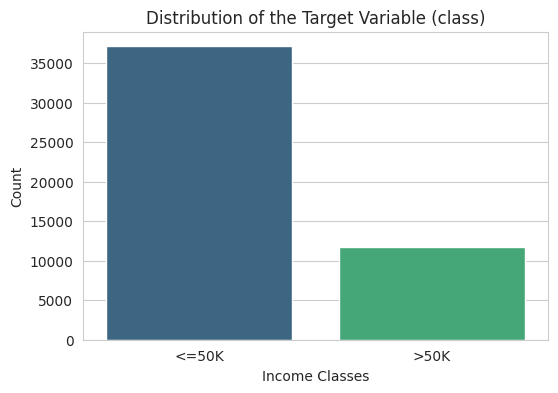

In [0]:
print(df["class"].value_counts())
print(df["class"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", palette="viridis")
plt.title("Distribution of the Target Variable (class)")
plt.xlabel("Income Classes")
plt.ylabel("Count")
plt.show()

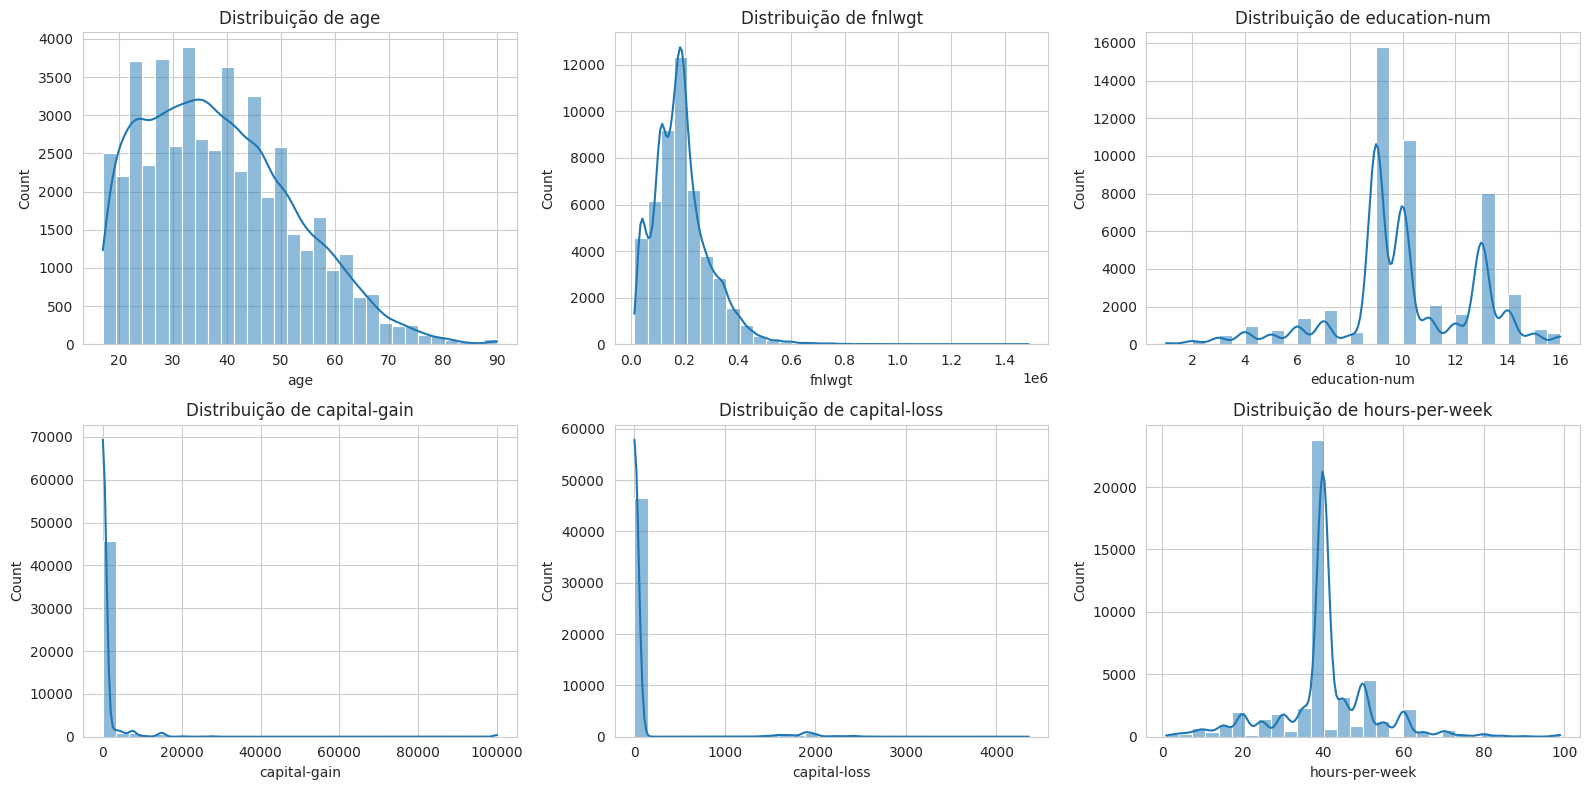

In [0]:
num_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"Distribuição de {col}")

plt.tight_layout()
plt.show()

### Qtd. de item por Coluna

In [0]:
cat_cols = ["workclass", "education", "marital-status", "occupation",
            "relationship", "race", "sex", "native-country"]

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- workclass ---
workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
unemployed           2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
Name: count, dtype: int64

--- marital-status ---
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial      6082
Adm-clerical         5606
Sales              

/home/spark-891c099e-d2ce-4e18-94bb-dd/.ipykernel/86/command-4547108429476573-800063311:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
/home/spark-891c099e-d2ce-4e18-94bb-dd/.ipykernel/86/command-4547108429476573-800063311:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
/home/spark-891c099e-d2ce-4e18-94bb-dd/.ipykernel/86/command-4547108429476573-800063311:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y

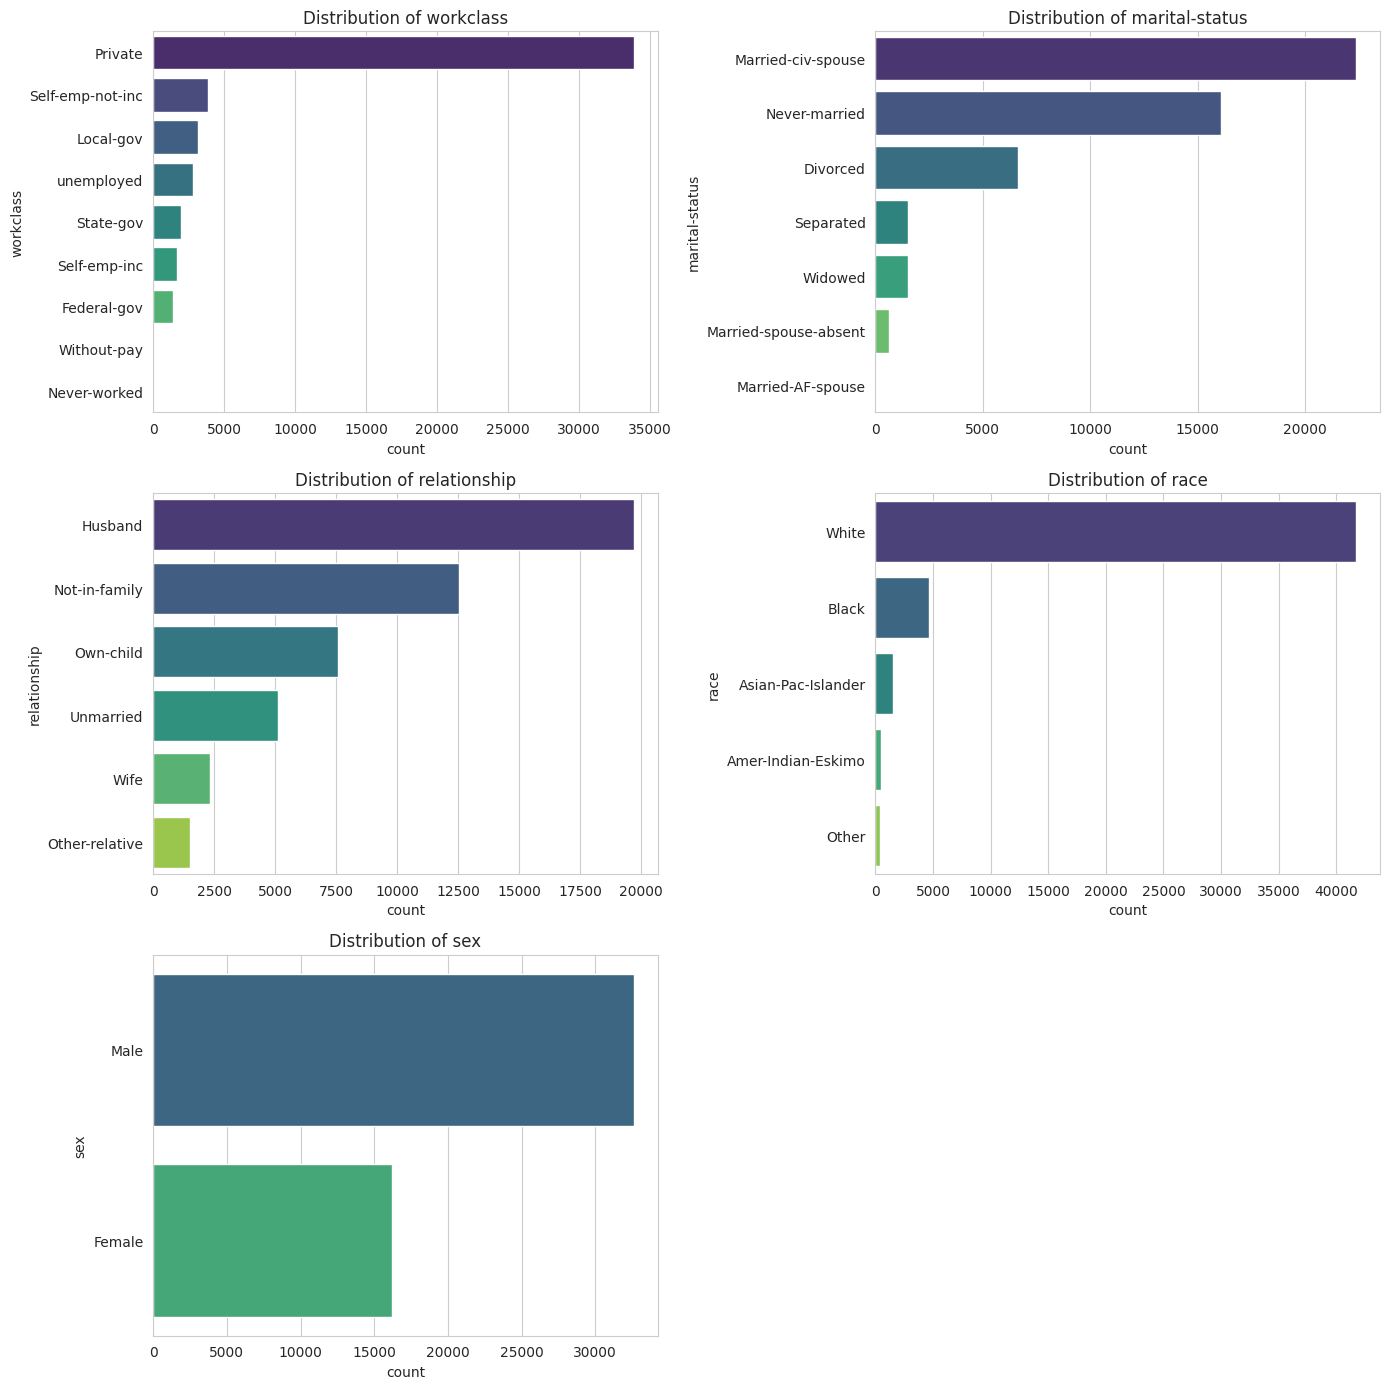

In [0]:
# Visualização das categóricas com menos níveis
cat_cols_plot = ["workclass", "marital-status", "relationship", "race", "sex"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribution of {col}")

fig.delaxes(axes[-1])  # remove eixo vazio
plt.tight_layout()
plt.show()

### Matriz de Correlação (Vár. Numéricas)*Texto em itálico*

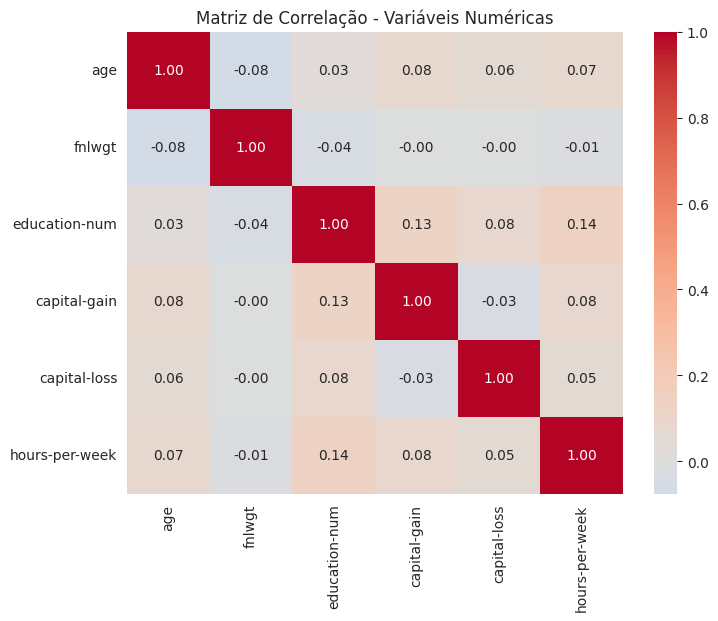

In [0]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

**Análise correlação:** baixa ou nenhuma correlação entre as colunas atuais da tabela.

### Análise Outliers

In [0]:
num_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
    return outliers, limite_inf, limite_sup

for col in num_cols:
    outliers, li, ls = detectar_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%) "
          f"| Limites: [{li:.2f}, {ls:.2f}]")

age: 215 outliers (0.44%) | Limites: [-2.00, 78.00]
fnlwgt: 1453 outliers (2.98%) | Limites: [-62521.88, 417683.12]
education-num: 1787 outliers (3.66%) | Limites: [4.50, 16.50]
capital-gain: 4035 outliers (8.27%) | Limites: [0.00, 0.00]
capital-loss: 2282 outliers (4.68%) | Limites: [0.00, 0.00]
hours-per-week: 13486 outliers (27.64%) | Limites: [32.50, 52.50]


In [0]:
from scipy import stats

for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = df[z_scores > 3]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

age: 185 outliers (0.38%)
fnlwgt: 506 outliers (1.04%)
education-num: 326 outliers (0.67%)
capital-gain: 331 outliers (0.68%)
capital-loss: 2216 outliers (4.54%)
hours-per-week: 681 outliers (1.40%)


### Boxplot_1

/home/spark-891c099e-d2ce-4e18-94bb-dd/.ipykernel/86/command-4547108429476581-3803698215:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=col, ax=axes[i], palette="viridis")
/home/spark-891c099e-d2ce-4e18-94bb-dd/.ipykernel/86/command-4547108429476581-3803698215:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y=col, ax=axes[i], palette="viridis")
/home/spark-891c099e-d2ce-4e18-94bb-dd/.ipykernel/86/command-4547108429476581-3803698215:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class

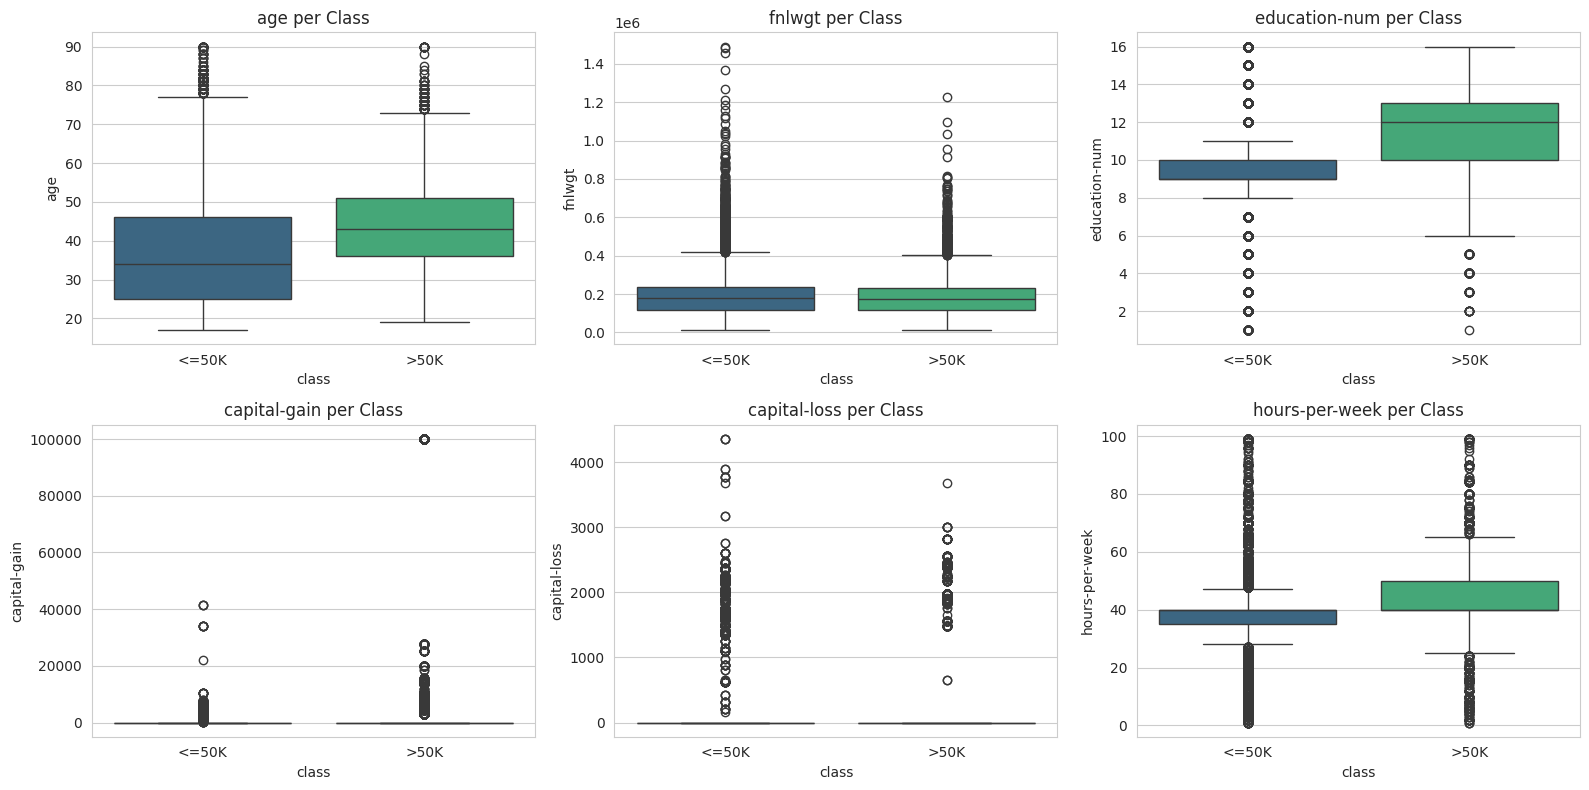

In [0]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="class", y=col, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{col} per Class")

plt.tight_layout()
plt.show()

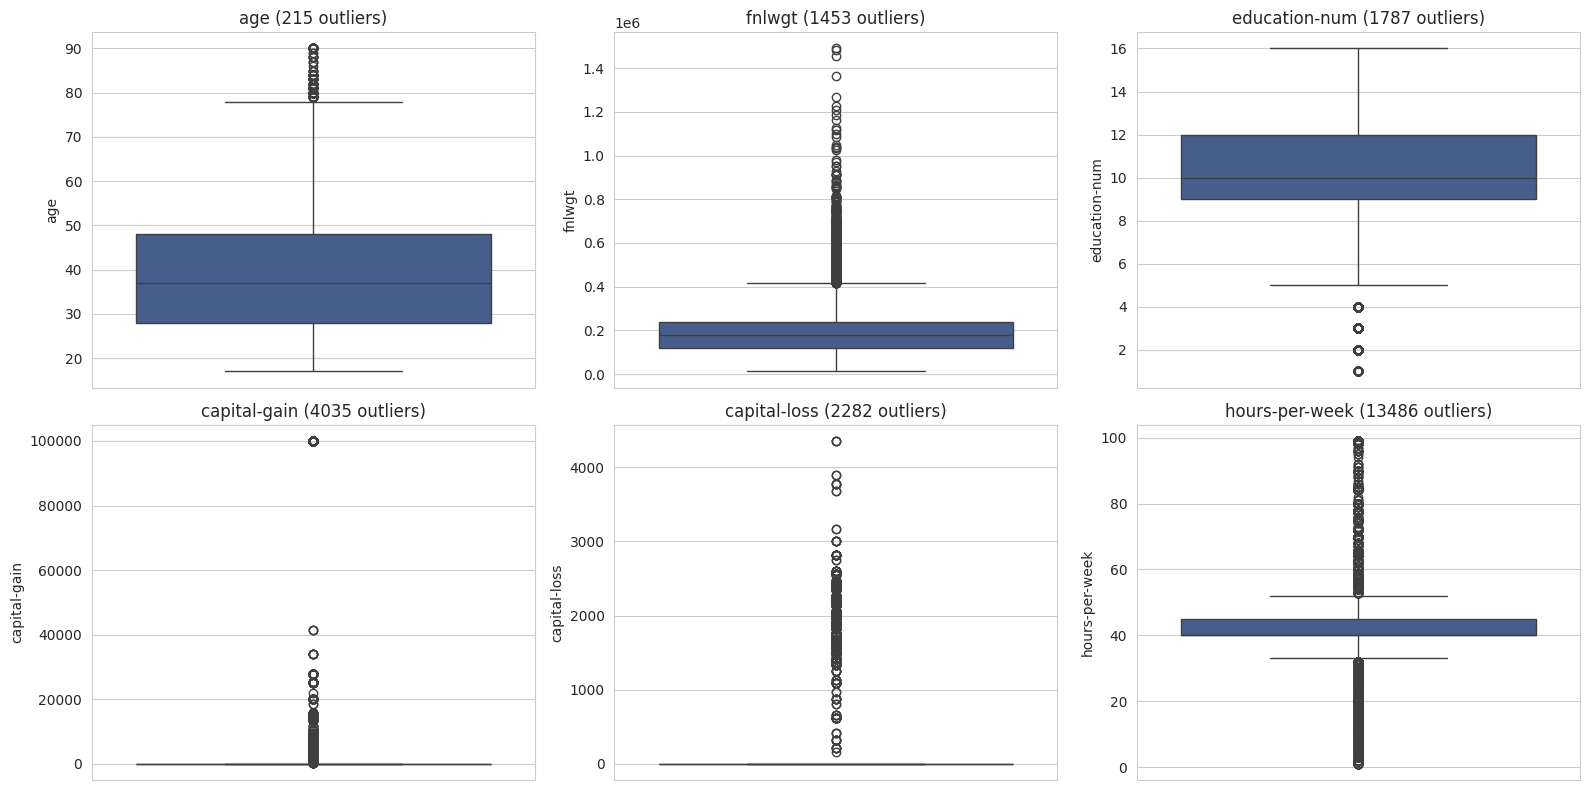

In [0]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color="#3b5998")
    outliers, _, _ = detectar_outliers_iqr(df, col)
    axes[i].set_title(f"{col} ({len(outliers)} outliers)")

plt.tight_layout()
plt.show()

**Análise Boxplots:**

1) **capital-gain' e 'capital-loss':** confirmação do problema, onde 75% dos indivíduos tem valor 0.
2) **age, education-num**: scaling adequado, outliers são naturais, sem ação necessária.
3) **fnlwgt:** considerar remover do modelo ou aplicar log-transform; distribuição muito assimétrica.
4) **hours-per-week:** investigar se vale a pena criar uma feature categórica (ex: "part-time" / "full-time" / "overtime") em vez de tratar como puramente contínua

In [0]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df["outlier_iso"] = iso.fit_predict(df[num_cols])

# -1 = outlier, 1 = normal
print(df["outlier_iso"].value_counts())
print(f"\nOutliers detectados: {(df['outlier_iso'] == -1).sum()}")

outlier_iso
 1    46350
-1     2440
Name: count, dtype: int64

Outliers detectados: 2440


### Escalonamento das variáveis numéricas

In [0]:
from sklearn.preprocessing import RobustScaler

num_cols = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

# Cria uma cópia só para fins de EDA, sem alterar o df original
df_scaled = df.copy()

scaler_eda = RobustScaler()
df_scaled[num_cols] = scaler_eda.fit_transform(df_scaled[num_cols])

df_scaled[num_cols].describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48790.000000,48790.000000,48790.000000,48790.000000,48790.000000,48790.000000
mean,0.082640,0.096046,0.026269,1080.217688,87.595573,0.085177
std,0.685425,0.879768,0.856682,7455.905921,403.209129,2.478546
min,-1.000000,-1.381522,-3.000000,0.000000,0.000000,-7.800000
25%,-0.450000,-0.504647,-0.333333,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.550000,0.495353,0.666667,0.000000,0.000000,1.000000
max,2.650000,10.930844,2.000000,99999.000000,4356.000000,11.800000


**Análise Escalonamento:**
1) Scaling nas colunas capital-gain e capital-loss é ineficaz, por conta de existirem muitos valores a zero nessa coluna.

 - Solução proposta: criar feature binária 'is_capital_gain'.